In [24]:
%load_ext autoreload
%autoreload 2

import ast
import contextlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from table_generator import aggregate_across_seeds

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# ------------------------------------------------------------------
# Load data and aggregate across seeds
# ------------------------------------------------------------------
csv_filename = "hopse_hyperparam_runs.csv"
df_raw = pd.read_csv(csv_filename, low_memory=False)
print(df_raw.shape)
aggregated_df = aggregate_across_seeds(
    df_raw,
    metric_prefix="summary.",
    output_filename=None,
)
print(f"Seed-aggregated shape: {aggregated_df.shape}")
aggregated_df.head()

(61451, 446)
▶ Seed column: dataset.split_params.data_seed
▶ All seed columns excluded from grouping: ['dataset.parameters.data_seed', 'dataset.split_params.data_seed', 'seed']
▶ Backfilled 9038/24633 missing seeds from run_name
▶ Dropping 15595 runs with no seed info at all
▶ Expected seeds per group: 5
▶ Found 173 metric columns with prefix 'summary.'
▶ Initial grouping candidates (after dropping bad cols): 255


/home/louisa/code/topobench/table_generator.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Separator to join nested keys.


▶ Dropped 4 per-run columns (nunique > 9171):
    nunique= 31736  paths.output_dir
    nunique= 31736  logger.wandb.save_dir
    nunique= 31736  trainer.default_root_dir
    nunique= 31736  callbacks.model_checkpoint.dirpath
▶ Final grouping columns (after nunique filter): 251
▶ Numeric metric columns kept: 128
▶ Dropped 45 all-NaN / non-numeric metric columns (e.g.): ['summary.AvgTime/train_batch_mean', 'summary.AvgTime/train_batch_std', 'summary.AvgTime/train_epoch_mean', 'summary.AvgTime/train_epoch_std', 'summary.AvgTime/val_batch_mean']
▶ Filtering: 371 groups removed (did not have exactly 5 seeds)
▶ Keeping: 8539 groups with exactly 5 seeds


/home/louisa/code/topobench/table_generator.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  


▶ Aggregated shape: (8539, 635)
▶ Number of unique experiment configurations: 8539
Seed-aggregated shape: (8539, 635)


/home/louisa/code/topobench/table_generator.py:116: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ----------


,loss._target_,loss.dataset_loss.task,loss.dataset_loss.loss_type,loss.modules_losses.readout,loss.modules_losses.backbone,loss.modules_losses.feature_encoder,tags,test,model.compile,model.readout.max_hop,...,summary.val_best_rerun/precision-2_count,summary.val_best_rerun/recall-0,summary.val_best_rerun/recall-0_std,summary.val_best_rerun/recall-0_count,summary.val_best_rerun/recall-1,summary.val_best_rerun/recall-1_std,summary.val_best_rerun/recall-1_count,summary.val_best_rerun/recall-2,summary.val_best_rerun/recall-2_std,summary.val_best_rerun/recall-2_count
0,__val__:'topobench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,"__val__:""['dev']""",__val__:True,__val__:False,__val__:5.0,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0
1,__val__:'topobench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,"__val__:""['dev']""",__val__:True,__val__:False,__val__:5.0,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0
2,__val__:'topobench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,"__val__:""['dev']""",__val__:True,__val__:False,__val__:5.0,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0
3,__val__:'topobench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,"__val__:""['dev']""",__val__:True,__val__:False,__val__:5.0,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0
4,__val__:'topobench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,"__val__:""['dev']""",__val__:True,__val__:False,__val__:5.0,...,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0


In [15]:
# ------------------------------------------------------------------
# Shared utilities: decoding, naming, colours
# ------------------------------------------------------------------


def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:") :]
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x


CANONICAL_MODEL_ORDER = ["gcn", "gat", "hopse_m"]

MODEL_DISPLAY_NAMES = {
    "gcn": "GCN",
    "gat": "GAT",
    "hopse_m": "HOPSE",
}

DATASET_DISPLAY_NAMES = {
    "Cora": "Cora",
    "citeseer": "Citeseer",
    "PubMed": "PubMed",
    "PROTEINS": "PROTEINS",
    "MUTAG": "MUTAG",
    "NCI1": "NCI1",
    "NCI109": "NCI109",
    "ZINC": "ZINC",
    "MANTRA_name": "MANTRA (name)",
    "MANTRA_orientation": "MANTRA (orient.)",
    "MANTRA_betti_numbers": "MANTRA (Betti)",
}

MODEL_COLORS = {
    "gcn": "#E85D04",
    "gat": "#5B9BD5",
    "hopse_m": "#7B2CBF",
}


def get_display_name(m):
    return MODEL_DISPLAY_NAMES.get(m, m)


def get_dataset_display_name(d):
    return DATASET_DISPLAY_NAMES.get(d, d.title())


# ------------------------------------------------------------------
# Prepare the working dataframe
# ------------------------------------------------------------------
MODEL_COL = "model.model_name"
DATA_COL = "dataset.loader.parameters.data_name"
METRIC_COL = "summary.test_best_rerun/accuracy"
METRIC_STD_COL = f"{METRIC_COL}_std"
LR_COL = "optimizer.parameters.lr"
WD_COL = "optimizer.parameters.weight_decay"
OUTCH_COL = "model.feature_encoder.out_channels"
NLAYERS_COL = "model.backbone.num_layers"
PROJ_DROPOUT_COL = "model.feature_encoder.proj_dropout"
BATCH_SIZE_COL = "dataset.dataloader_params.batch_size"
NUM_LAYERS_COL = "model.backbone.n_layers"
ENC_COL = "transforms.hopse_encoding.encodings"

df = aggregated_df.copy()

for col in [
    MODEL_COL,
    DATA_COL,
    LR_COL,
    WD_COL,
    OUTCH_COL,
    NLAYERS_COL,
    ENC_COL,
]:
    if col in df.columns:
        df[col] = df[col].apply(_decode_val)

df[MODEL_COL] = df[MODEL_COL].apply(
    lambda x: x.lower() if isinstance(x, str) else x
)

for col in [
    METRIC_COL,
    METRIC_STD_COL,
    LR_COL,
    WD_COL,
    OUTCH_COL,
    NLAYERS_COL,
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[MODEL_COL, DATA_COL, METRIC_COL])

models_in_data = set(df[MODEL_COL].dropna().unique())
all_models = [m for m in CANONICAL_MODEL_ORDER if m in models_in_data]
datasets = sorted(df[DATA_COL].unique())

print(f"Working dataframe: {len(df)} seed-aggregated configurations")
print(f"Models: {[get_display_name(m) for m in all_models]}")
print(f"Datasets: {datasets}")
print(f"LR values: {sorted(df[LR_COL].dropna().unique())}")
print(f"Weight decay values: {sorted(df[WD_COL].dropna().unique())}")
print(f"Out channels values: {sorted(df[OUTCH_COL].dropna().unique())}")
print(f"Num layers values: {sorted(df[NLAYERS_COL].dropna().unique())}")

Working dataframe: 6404 seed-aggregated configurations
Models: ['GCN', 'GAT', 'HOPSE']
Datasets: ['Cora', 'MANTRA_name', 'MANTRA_orientation', 'MUTAG', 'NCI1', 'NCI109', 'PROTEINS', 'PubMed', 'citeseer']
LR values: [np.float64(0.001), np.float64(0.01)]
Weight decay values: [np.float64(0.0), np.float64(0.0001)]
Out channels values: [np.float64(128.0), np.float64(256.0)]
Num layers values: [np.float64(1.0), np.float64(2.0), np.float64(4.0)]


In [ ]:
# ------------------------------------------------------------------
# Marginal Effect of Learning Rate on Test Accuracy
#
# For each (model, dataset), we collect the test accuracy from ALL
# seed-aggregated configurations, split by LR value.
# Violin + strip plots show the full distribution; a Wilcoxon
# signed-rank test on paired configs assesses statistical significance.
# ------------------------------------------------------------------

df_lr = df.dropna(subset=[LR_COL])
lr_values = sorted(df_lr[LR_COL].unique())

fig, axes = plt.subplots(
    len(datasets),
    len(all_models),
    figsize=(4 * len(all_models), 3.5 * len(datasets)),
    sharex="col",
    squeeze=False,
)
fig.suptitle(
    "Marginal Effect of Learning Rate on Test Accuracy\n(across all other hyperparameter settings)",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)

for i, dataset in enumerate(datasets):
    for j, model in enumerate(all_models):
        ax = axes[i, j]
        sub = df_lr[(df_lr[MODEL_COL] == model) & (df_lr[DATA_COL] == dataset)]

        if len(sub) == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_xticks([])
            continue

        plot_df = sub[[LR_COL, METRIC_COL]].copy()
        plot_df[LR_COL] = plot_df[LR_COL].astype(str)

        groups = [
            plot_df.loc[plot_df[LR_COL] == str(v), METRIC_COL].dropna().values
            for v in lr_values
        ]
        non_empty = [
            (v, g)
            for v, g in zip(lr_values, groups, strict=True)
            if len(g) > 0
        ]
        if not non_empty:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            continue

        parts = ax.violinplot(
            [g for _, g in non_empty],
            positions=range(len(non_empty)),
            showmeans=True,
            showmedians=True,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(MODEL_COLORS.get(model, "#999"))
            pc.set_alpha(0.4)
        parts["cmeans"].set_color("black")
        parts["cmedians"].set_color("gray")
        parts["cmedians"].set_linestyle("--")

        rng = np.random.default_rng(42)
        for k, (_v, g) in enumerate(non_empty):
            jitter = rng.uniform(-0.08, 0.08, size=len(g))
            ax.scatter(
                np.full_like(g, k) + jitter,
                g,
                color=MODEL_COLORS.get(model, "#999"),
                alpha=0.25,
                s=8,
                zorder=3,
            )

        if len(non_empty) == 2:
            try:
                group_cols = [
                    c
                    for c in df.columns
                    if c not in [LR_COL, METRIC_COL, METRIC_STD_COL]
                    and c in sub.columns
                    and not c.startswith("summary.")
                ]
                wide = sub.pivot_table(
                    index=group_cols, columns=LR_COL, values=METRIC_COL
                )
                wide = wide.dropna()
                if len(wide) >= 10:
                    stat, p = stats.wilcoxon(wide.iloc[:, 0], wide.iloc[:, 1])
                    sig = (
                        "***"
                        if p < 0.001
                        else "**"
                        if p < 0.01
                        else "*"
                        if p < 0.05
                        else "ns"
                    )
                    ax.set_xlabel(f"p={p:.3g} ({sig})", fontsize=10)
            except Exception:
                pass

        ax.set_xticks(range(len(non_empty)))
        ax.set_xticklabels([str(v) for v, _ in non_empty], fontsize=11)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)

        if i == 0:
            ax.set_title(
                get_display_name(model), fontsize=13, fontweight="bold", pad=8
            )
        if j == 0:
            ax.set_ylabel(
                get_dataset_display_name(dataset),
                fontsize=14,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Marginal Effect of Weight Decay on Test Accuracy
# ------------------------------------------------------------------

df_wd = df.dropna(subset=[WD_COL])
wd_values = sorted(df_wd[WD_COL].unique())

fig, axes = plt.subplots(
    len(datasets),
    len(all_models),
    figsize=(4 * len(all_models), 3.5 * len(datasets)),
    sharex="col",
    squeeze=False,
)
fig.suptitle(
    "Marginal Effect of Weight Decay on Test Accuracy\n(across all other hyperparameter settings)",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)

for i, dataset in enumerate(datasets):
    for j, model in enumerate(all_models):
        ax = axes[i, j]
        sub = df_wd[(df_wd[MODEL_COL] == model) & (df_wd[DATA_COL] == dataset)]

        if len(sub) == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_xticks([])
            continue

        plot_df = sub[[WD_COL, METRIC_COL]].copy()
        plot_df[WD_COL] = plot_df[WD_COL].astype(str)

        groups = [
            plot_df.loc[plot_df[WD_COL] == str(v), METRIC_COL].dropna().values
            for v in wd_values
        ]
        non_empty = [
            (v, g)
            for v, g in zip(wd_values, groups, strict=True)
            if len(g) > 0
        ]
        if not non_empty:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            continue

        parts = ax.violinplot(
            [g for _, g in non_empty],
            positions=range(len(non_empty)),
            showmeans=True,
            showmedians=True,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(MODEL_COLORS.get(model, "#999"))
            pc.set_alpha(0.4)
        parts["cmeans"].set_color("black")
        parts["cmedians"].set_color("gray")
        parts["cmedians"].set_linestyle("--")

        rng = np.random.default_rng(42)
        for k, (_v, g) in enumerate(non_empty):
            jitter = rng.uniform(-0.08, 0.08, size=len(g))
            ax.scatter(
                np.full_like(g, k) + jitter,
                g,
                color=MODEL_COLORS.get(model, "#999"),
                alpha=0.25,
                s=8,
                zorder=3,
            )

        if len(non_empty) == 2:
            try:
                group_cols = [
                    c
                    for c in df.columns
                    if c not in [WD_COL, METRIC_COL, METRIC_STD_COL]
                    and c in sub.columns
                    and not c.startswith("summary.")
                ]
                wide = sub.pivot_table(
                    index=group_cols, columns=WD_COL, values=METRIC_COL
                )
                wide = wide.dropna()
                if len(wide) >= 10:
                    stat, p = stats.wilcoxon(wide.iloc[:, 0], wide.iloc[:, 1])
                    sig = (
                        "***"
                        if p < 0.001
                        else "**"
                        if p < 0.01
                        else "*"
                        if p < 0.05
                        else "ns"
                    )
                    ax.set_xlabel(f"p={p:.3g} ({sig})", fontsize=10)
            except Exception:
                pass

        ax.set_xticks(range(len(non_empty)))
        ax.set_xticklabels([str(v) for v, _ in non_empty], fontsize=11)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)

        if i == 0:
            ax.set_title(
                get_display_name(model), fontsize=13, fontweight="bold", pad=8
            )
        if j == 0:
            ax.set_ylabel(
                get_dataset_display_name(dataset),
                fontsize=14,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

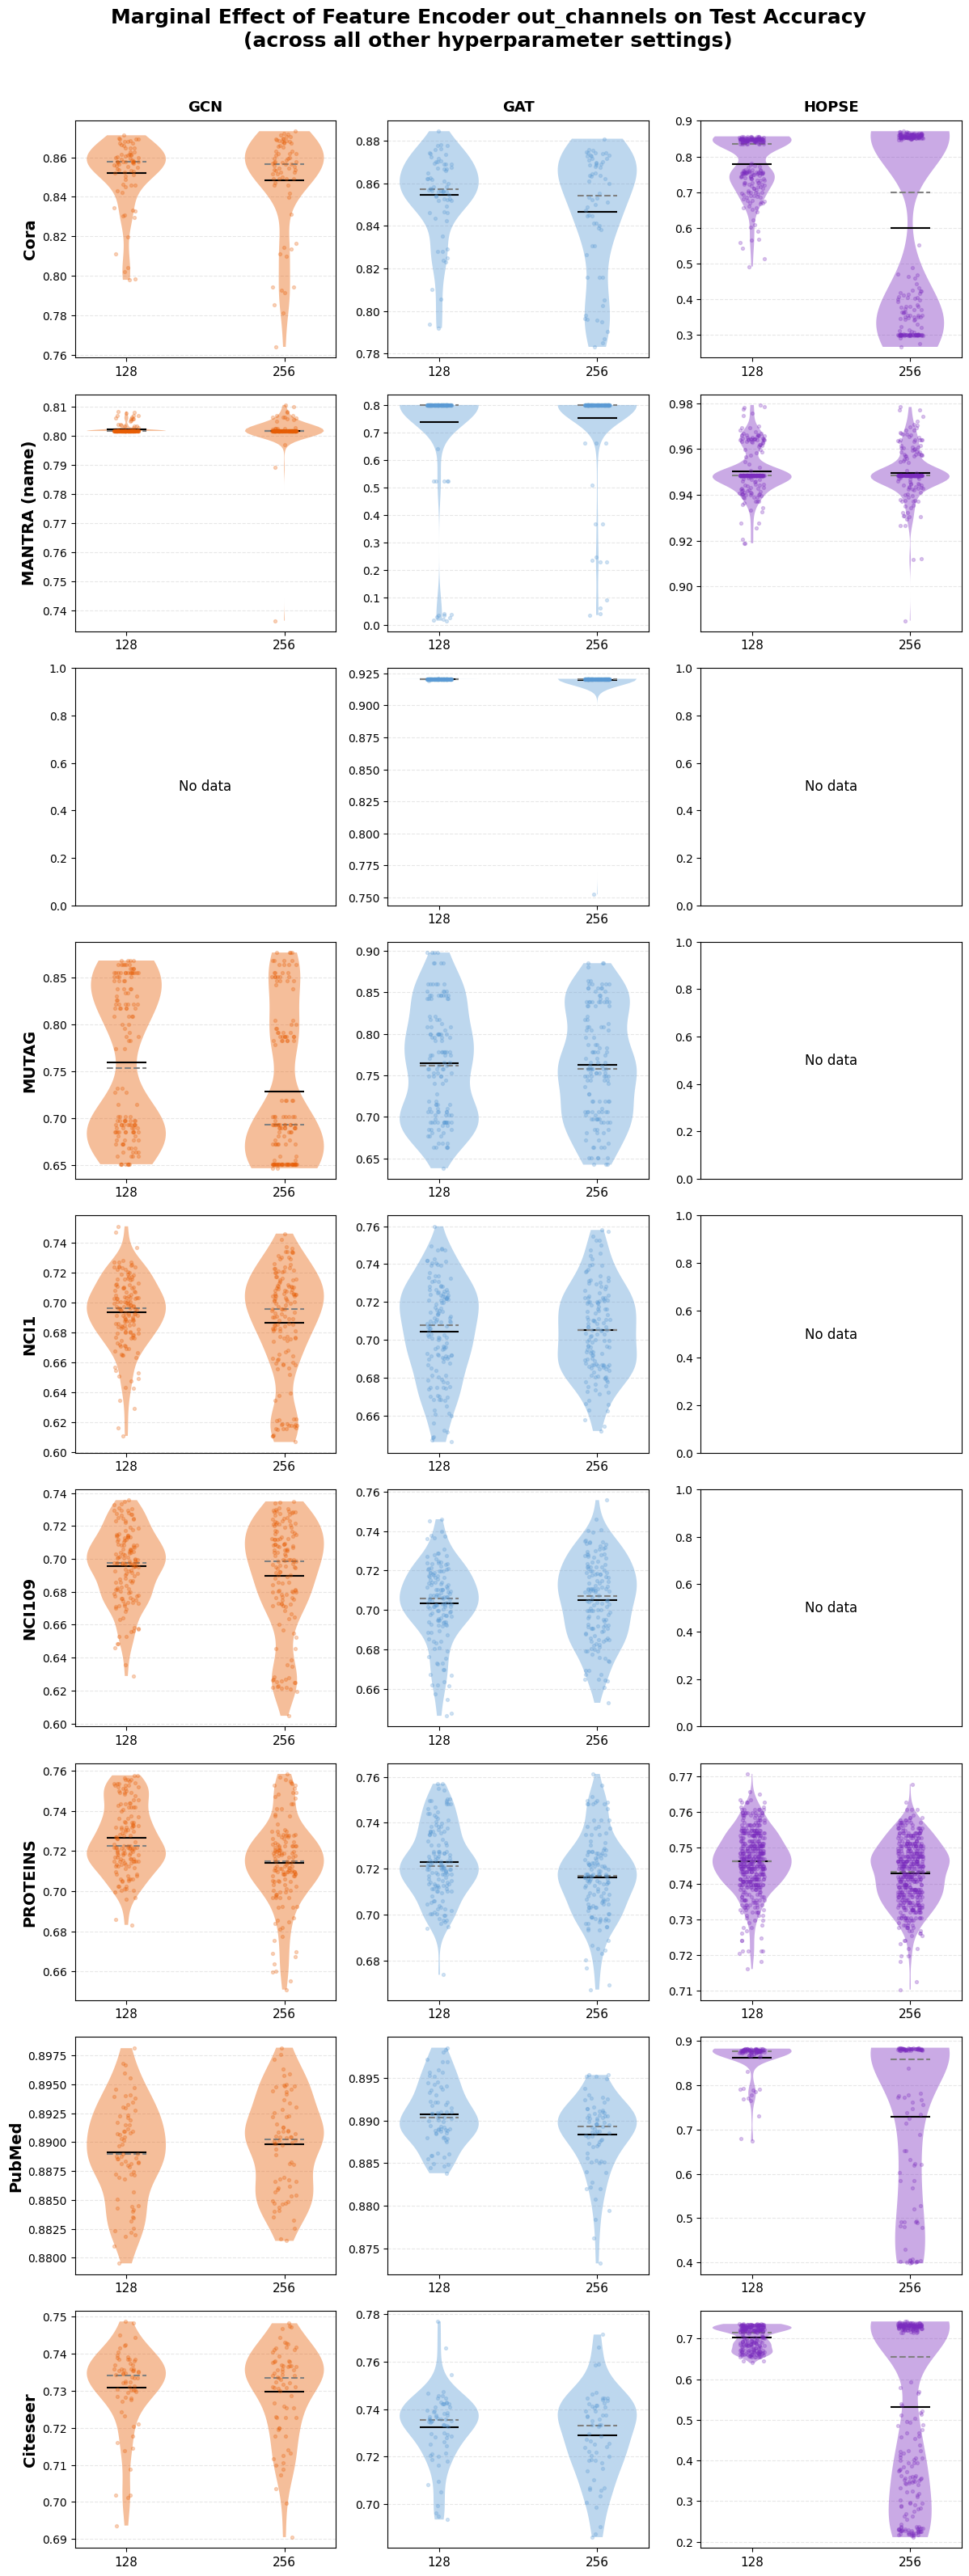

In [18]:
# ------------------------------------------------------------------
# Marginal Effect of Feature Encoder out_channels on Test Accuracy
#
# Violin + strip plots per (model, dataset).
# Wilcoxon signed-rank test for 2 groups, Kruskal-Wallis for >2.
# ------------------------------------------------------------------

df_outch = df.dropna(subset=[OUTCH_COL])

fig, axes = plt.subplots(
    len(datasets),
    len(all_models),
    figsize=(4 * len(all_models), 3.5 * len(datasets)),
    squeeze=False,
)
fig.suptitle(
    "Marginal Effect of Feature Encoder out_channels on Test Accuracy\n"
    "(across all other hyperparameter settings)",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)

for i, dataset in enumerate(datasets):
    for j, model in enumerate(all_models):
        ax = axes[i, j]
        sub = df_outch[
            (df_outch[MODEL_COL] == model) & (df_outch[DATA_COL] == dataset)
        ]

        if len(sub) == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_xticks([])
            continue

        local_vals = sorted(sub[OUTCH_COL].unique())

        groups = [
            sub.loc[sub[OUTCH_COL] == v, METRIC_COL].dropna().values
            for v in local_vals
        ]
        non_empty = [
            (v, g)
            for v, g in zip(local_vals, groups, strict=True)
            if len(g) > 0
        ]
        if len(non_empty) == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            continue

        local_vals = [v for v, _ in non_empty]
        groups = [g for _, g in non_empty]

        parts = ax.violinplot(
            groups,
            positions=range(len(local_vals)),
            showmeans=True,
            showmedians=True,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(MODEL_COLORS.get(model, "#999"))
            pc.set_alpha(0.4)
        parts["cmeans"].set_color("black")
        parts["cmedians"].set_color("gray")
        parts["cmedians"].set_linestyle("--")

        rng = np.random.default_rng(42)
        for k, (_v, g) in enumerate(zip(local_vals, groups, strict=True)):
            jitter = rng.uniform(-0.08, 0.08, size=len(g))
            ax.scatter(
                np.full_like(g, k) + jitter,
                g,
                color=MODEL_COLORS.get(model, "#999"),
                alpha=0.25,
                s=8,
                zorder=3,
            )

        if len(groups) == 2:
            try:
                group_cols = [
                    c
                    for c in df.columns
                    if c not in [OUTCH_COL, METRIC_COL, METRIC_STD_COL]
                    and c in sub.columns
                    and not c.startswith("summary.")
                ]
                wide = sub.pivot_table(
                    index=group_cols, columns=OUTCH_COL, values=METRIC_COL
                )
                wide = wide.dropna()
                if len(wide) >= 10:
                    stat, p = stats.wilcoxon(wide.iloc[:, 0], wide.iloc[:, 1])
                    sig = (
                        "***"
                        if p < 0.001
                        else "**"
                        if p < 0.01
                        else "*"
                        if p < 0.05
                        else "ns"
                    )
                    ax.set_xlabel(f"p={p:.3g} ({sig})", fontsize=10)
            except Exception:
                pass
        elif len(groups) >= 3:
            try:
                stat, p = stats.kruskal(*groups)
                sig = (
                    "***"
                    if p < 0.001
                    else "**"
                    if p < 0.01
                    else "*"
                    if p < 0.05
                    else "ns"
                )
                ax.set_xlabel(f"KW p={p:.3g} ({sig})", fontsize=10)
            except Exception:
                pass

        ax.set_xticks(range(len(local_vals)))
        ax.set_xticklabels([str(int(v)) for v in local_vals], fontsize=11)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)

        if i == 0:
            ax.set_title(
                get_display_name(model), fontsize=13, fontweight="bold", pad=8
            )
        if j == 0:
            ax.set_ylabel(
                get_dataset_display_name(dataset),
                fontsize=14,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Marginal Effect of proj dropout on Test Accuracy
# ------------------------------------------------------------------

df_wd = df.dropna(subset=[PROJ_DROPOUT_COL])
wd_values = sorted(df_wd[PROJ_DROPOUT_COL].unique())

fig, axes = plt.subplots(
    len(datasets),
    len(all_models),
    figsize=(4 * len(all_models), 3.5 * len(datasets)),
    sharex="col",
    squeeze=False,
)
fig.suptitle(
    "Marginal Effect of proj dropout on Test Accuracy\n(across all other hyperparameter settings)",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)

for i, dataset in enumerate(datasets):
    for j, model in enumerate(all_models):
        ax = axes[i, j]
        sub = df_wd[(df_wd[MODEL_COL] == model) & (df_wd[DATA_COL] == dataset)]

        if len(sub) == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_xticks([])
            continue

        plot_df = sub[[PROJ_DROPOUT_COL, METRIC_COL]].copy()
        plot_df[PROJ_DROPOUT_COL] = plot_df[PROJ_DROPOUT_COL].astype(str)

        groups = [
            plot_df.loc[plot_df[PROJ_DROPOUT_COL] == str(v), METRIC_COL]
            .dropna()
            .values
            for v in wd_values
        ]
        non_empty = [
            (v, g)
            for v, g in zip(wd_values, groups, strict=True)
            if len(g) > 0
        ]
        if not non_empty:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            continue

        parts = ax.violinplot(
            [g for _, g in non_empty],
            positions=range(len(non_empty)),
            showmeans=True,
            showmedians=True,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(MODEL_COLORS.get(model, "#999"))
            pc.set_alpha(0.4)
        parts["cmeans"].set_color("black")
        parts["cmedians"].set_color("gray")
        parts["cmedians"].set_linestyle("--")

        rng = np.random.default_rng(42)
        for k, (_v, g) in enumerate(non_empty):
            jitter = rng.uniform(-0.08, 0.08, size=len(g))
            ax.scatter(
                np.full_like(g, k) + jitter,
                g,
                color=MODEL_COLORS.get(model, "#999"),
                alpha=0.25,
                s=8,
                zorder=3,
            )

        if len(non_empty) == 2:
            try:
                group_cols = [
                    c
                    for c in df.columns
                    if c not in [PROJ_DROPOUT_COL, METRIC_COL, METRIC_STD_COL]
                    and c in sub.columns
                    and not c.startswith("summary.")
                ]
                wide = sub.pivot_table(
                    index=group_cols,
                    columns=PROJ_DROPOUT_COL,
                    values=METRIC_COL,
                )
                wide = wide.dropna()
                if len(wide) >= 10:
                    stat, p = stats.wilcoxon(wide.iloc[:, 0], wide.iloc[:, 1])
                    sig = (
                        "***"
                        if p < 0.001
                        else "**"
                        if p < 0.01
                        else "*"
                        if p < 0.05
                        else "ns"
                    )
                    ax.set_xlabel(f"p={p:.3g} ({sig})", fontsize=10)
            except Exception:
                pass

        ax.set_xticks(range(len(non_empty)))
        ax.set_xticklabels([str(v) for v, _ in non_empty], fontsize=11)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)

        if i == 0:
            ax.set_title(
                get_display_name(model), fontsize=13, fontweight="bold", pad=8
            )
        if j == 0:
            ax.set_ylabel(
                get_dataset_display_name(dataset),
                fontsize=14,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Marginal Effect of batch size on Test Accuracy
# ------------------------------------------------------------------

df_wd = df.dropna(subset=[BATCH_SIZE_COL])
wd_values = sorted(df_wd[BATCH_SIZE_COL].unique())

fig, axes = plt.subplots(
    len(datasets),
    len(all_models),
    figsize=(4 * len(all_models), 3.5 * len(datasets)),
    sharex="col",
    squeeze=False,
)
fig.suptitle(
    "Marginal Effect of batch size on Test Accuracy\n(across all other hyperparameter settings)",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)

for i, dataset in enumerate(datasets):
    for j, model in enumerate(all_models):
        ax = axes[i, j]
        sub = df_wd[(df_wd[MODEL_COL] == model) & (df_wd[DATA_COL] == dataset)]

        if len(sub) == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_xticks([])
            continue

        plot_df = sub[[BATCH_SIZE_COL, METRIC_COL]].copy()
        plot_df[BATCH_SIZE_COL] = plot_df[BATCH_SIZE_COL].astype(str)

        groups = [
            plot_df.loc[plot_df[BATCH_SIZE_COL] == str(v), METRIC_COL]
            .dropna()
            .values
            for v in wd_values
        ]
        non_empty = [
            (v, g)
            for v, g in zip(wd_values, groups, strict=True)
            if len(g) > 0
        ]
        if not non_empty:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            continue

        parts = ax.violinplot(
            [g for _, g in non_empty],
            positions=range(len(non_empty)),
            showmeans=True,
            showmedians=True,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(MODEL_COLORS.get(model, "#999"))
            pc.set_alpha(0.4)
        parts["cmeans"].set_color("black")
        parts["cmedians"].set_color("gray")
        parts["cmedians"].set_linestyle("--")

        rng = np.random.default_rng(42)
        for k, (_v, g) in enumerate(non_empty):
            jitter = rng.uniform(-0.08, 0.08, size=len(g))
            ax.scatter(
                np.full_like(g, k) + jitter,
                g,
                color=MODEL_COLORS.get(model, "#999"),
                alpha=0.25,
                s=8,
                zorder=3,
            )

        if len(non_empty) == 2:
            try:
                group_cols = [
                    c
                    for c in df.columns
                    if c not in [BATCH_SIZE_COL, METRIC_COL, METRIC_STD_COL]
                    and c in sub.columns
                    and not c.startswith("summary.")
                ]
                wide = sub.pivot_table(
                    index=group_cols, columns=BATCH_SIZE_COL, values=METRIC_COL
                )
                wide = wide.dropna()
                if len(wide) >= 10:
                    stat, p = stats.wilcoxon(wide.iloc[:, 0], wide.iloc[:, 1])
                    sig = (
                        "***"
                        if p < 0.001
                        else "**"
                        if p < 0.01
                        else "*"
                        if p < 0.05
                        else "ns"
                    )
                    ax.set_xlabel(f"p={p:.3g} ({sig})", fontsize=10)
            except Exception:
                pass

        ax.set_xticks(range(len(non_empty)))
        ax.set_xticklabels([str(v) for v, _ in non_empty], fontsize=11)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)

        if i == 0:
            ax.set_title(
                get_display_name(model), fontsize=13, fontweight="bold", pad=8
            )
        if j == 0:
            ax.set_ylabel(
                get_dataset_display_name(dataset),
                fontsize=14,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Marginal Effect of batch size on Test Accuracy
# ------------------------------------------------------------------

df_wd = df.dropna(subset=[NUM_LAYERS_COL])
wd_values = sorted(df_wd[NUM_LAYERS_COL].unique())

fig, axes = plt.subplots(
    len(datasets),
    len(all_models),
    figsize=(4 * len(all_models), 3.5 * len(datasets)),
    sharex="col",
    squeeze=False,
)
fig.suptitle(
    "Marginal Effect of batch size on Test Accuracy\n(across all other hyperparameter settings)",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)

for i, dataset in enumerate(datasets):
    for j, model in enumerate(all_models):
        ax = axes[i, j]
        sub = df_wd[(df_wd[MODEL_COL] == model) & (df_wd[DATA_COL] == dataset)]

        if len(sub) == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_xticks([])
            continue

        plot_df = sub[[NUM_LAYERS_COL, METRIC_COL]].copy()
        plot_df[NUM_LAYERS_COL] = plot_df[NUM_LAYERS_COL].astype(str)

        groups = [
            plot_df.loc[plot_df[NUM_LAYERS_COL] == str(v), METRIC_COL]
            .dropna()
            .values
            for v in wd_values
        ]
        non_empty = [
            (v, g)
            for v, g in zip(wd_values, groups, strict=True)
            if len(g) > 0
        ]
        if not non_empty:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            continue

        parts = ax.violinplot(
            [g for _, g in non_empty],
            positions=range(len(non_empty)),
            showmeans=True,
            showmedians=True,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(MODEL_COLORS.get(model, "#999"))
            pc.set_alpha(0.4)
        parts["cmeans"].set_color("black")
        parts["cmedians"].set_color("gray")
        parts["cmedians"].set_linestyle("--")

        rng = np.random.default_rng(42)
        for k, (_v, g) in enumerate(non_empty):
            jitter = rng.uniform(-0.08, 0.08, size=len(g))
            ax.scatter(
                np.full_like(g, k) + jitter,
                g,
                color=MODEL_COLORS.get(model, "#999"),
                alpha=0.25,
                s=8,
                zorder=3,
            )

        if len(non_empty) == 2:
            try:
                group_cols = [
                    c
                    for c in df.columns
                    if c not in [NUM_LAYERS_COL, METRIC_COL, METRIC_STD_COL]
                    and c in sub.columns
                    and not c.startswith("summary.")
                ]
                wide = sub.pivot_table(
                    index=group_cols, columns=NUM_LAYERS_COL, values=METRIC_COL
                )
                wide = wide.dropna()
                if len(wide) >= 10:
                    stat, p = stats.wilcoxon(wide.iloc[:, 0], wide.iloc[:, 1])
                    sig = (
                        "***"
                        if p < 0.001
                        else "**"
                        if p < 0.01
                        else "*"
                        if p < 0.05
                        else "ns"
                    )
                    ax.set_xlabel(f"p={p:.3g} ({sig})", fontsize=10)
            except Exception:
                pass

        ax.set_xticks(range(len(non_empty)))
        ax.set_xticklabels([str(v) for v, _ in non_empty], fontsize=11)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)

        if i == 0:
            ax.set_title(
                get_display_name(model), fontsize=13, fontweight="bold", pad=8
            )
        if j == 0:
            ax.set_ylabel(
                get_dataset_display_name(dataset),
                fontsize=14,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

Runs with encoding info: 2453
Group counts:
_encoding_group
FE     1228
PSE    1225
Name: count, dtype: int64


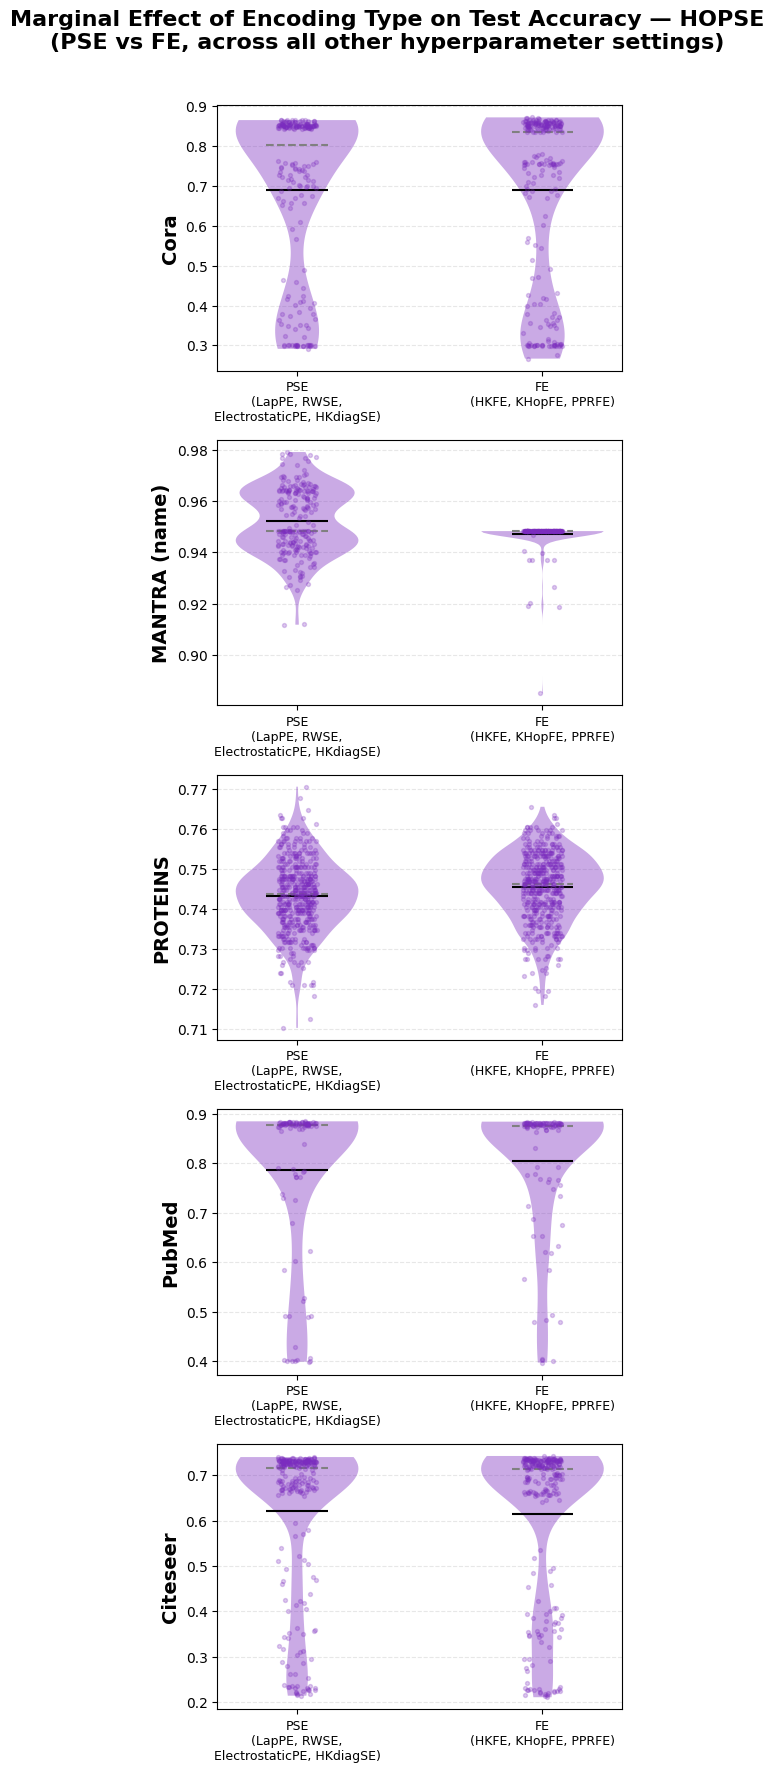

In [ ]:
# ------------------------------------------------------------------
# Marginal Effect of HOPSE Encoding Type on Test Accuracy
#
# Compares PSE encodings (LapPE, RWSE, ElectrostaticPE, HKdiagSE)
# vs FE encodings (HKFE, KHopFE, PPRFE).
# ------------------------------------------------------------------

ENC_GROUP_COL = "_encoding_group"

PSE_SET = frozenset(["LapPE", "RWSE", "ElectrostaticPE", "HKdiagSE"])
FE_SET = frozenset(["HKFE", "KHopFE", "PPRFE"])

ENCODING_LABELS = {
    "PSE": "PSE\n(LapPE, RWSE,\nElectrostaticPE, HKdiagSE)",
    "FE": "FE\n(HKFE, KHopFE, PPRFE)",
}
ENC_GROUP_ORDER = ["PSE", "FE"]


def _classify_encoding(raw):
    """Map the decoded encodings value to 'PSE' or 'FE'."""
    if pd.isna(raw):
        return np.nan
    if isinstance(raw, str):
        with contextlib.suppress(Exception):
            raw = ast.literal_eval(raw)
    if isinstance(raw, (list, tuple)):
        s = frozenset(raw)
        if s == PSE_SET:
            return "PSE"
        if s == FE_SET:
            return "FE"
    return np.nan


df[ENC_GROUP_COL] = df[ENC_COL].apply(_classify_encoding)
df_enc = df.dropna(subset=[ENC_GROUP_COL])

print(f"Runs with encoding info: {len(df_enc)}")
print(f"Group counts:\n{df_enc[ENC_GROUP_COL].value_counts()}")

enc_model = "hopse_m"
enc_datasets = sorted(
    df_enc[df_enc[MODEL_COL] == enc_model][DATA_COL].unique()
)

fig, axes = plt.subplots(
    len(enc_datasets),
    1,
    figsize=(5, 3.5 * len(enc_datasets)),
    squeeze=False,
)
fig.suptitle(
    f"Marginal Effect of Encoding Type on Test Accuracy — {get_display_name(enc_model)}\n"
    "(PSE vs FE, across all other hyperparameter settings)",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)

for i, dataset in enumerate(enc_datasets):
    ax = axes[i, 0]
    sub = df_enc[
        (df_enc[MODEL_COL] == enc_model) & (df_enc[DATA_COL] == dataset)
    ]

    groups = [
        sub.loc[sub[ENC_GROUP_COL] == g, METRIC_COL].dropna().values
        for g in ENC_GROUP_ORDER
    ]
    non_empty = [
        (g, vals)
        for g, vals in zip(ENC_GROUP_ORDER, groups, strict=True)
        if len(vals) > 0
    ]
    if not non_empty:
        ax.text(
            0.5,
            0.5,
            "No data",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=12,
        )
        continue

    parts = ax.violinplot(
        [vals for _, vals in non_empty],
        positions=range(len(non_empty)),
        showmeans=True,
        showmedians=True,
        showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(MODEL_COLORS.get(enc_model, "#999"))
        pc.set_alpha(0.4)
    parts["cmeans"].set_color("black")
    parts["cmedians"].set_color("gray")
    parts["cmedians"].set_linestyle("--")

    rng = np.random.default_rng(42)
    for k, (_g, vals) in enumerate(non_empty):
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(
            np.full_like(vals, k) + jitter,
            vals,
            color=MODEL_COLORS.get(enc_model, "#999"),
            alpha=0.25,
            s=8,
            zorder=3,
        )

    if len(non_empty) == 2:
        try:
            group_cols = [
                c
                for c in df.columns
                if c
                not in [
                    ENC_COL,
                    ENC_GROUP_COL,
                    METRIC_COL,
                    METRIC_STD_COL,
                ]
                and c in sub.columns
                and not c.startswith("summary.")
            ]
            wide = sub.pivot_table(
                index=group_cols,
                columns=ENC_GROUP_COL,
                values=METRIC_COL,
            )
            wide = wide.dropna()
            if len(wide) >= 10:
                stat, p = stats.wilcoxon(wide.iloc[:, 0], wide.iloc[:, 1])
                sig = (
                    "***"
                    if p < 0.001
                    else "**"
                    if p < 0.01
                    else "*"
                    if p < 0.05
                    else "ns"
                )
                ax.set_xlabel(f"p={p:.3g} ({sig})", fontsize=10)
        except Exception:
            pass

    ax.set_xticks(range(len(non_empty)))
    ax.set_xticklabels(
        [ENCODING_LABELS.get(g, g) for g, _ in non_empty], fontsize=9
    )
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_ylabel(
        get_dataset_display_name(dataset),
        fontsize=14,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()